# HOG & LBP Image Features for Computer Vision

## Learning Objectives
- Understand HOG (Histogram of Oriented Gradients) features
  - Cell structure, blocks, normalization
- Learn LBP (Local Binary Pattern) texture features
- Extract and visualize features from images
- Train SVM classifier on CIFAR-10 using HOG features
- Compare feature effectiveness

---

## Part 1: Setup & Libraries

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn scikit-image

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import seaborn as sns

# scikit-image for HOG and LBP
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
from skimage.io import imread

# Machine learning
from sklearn.datasets import load_sample_image
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, f1_score)

# CIFAR-10 data
import urllib.request
import pickle
import os

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

✓ All libraries imported successfully!
OpenCV version: 4.13.0
NumPy version: 2.4.0


---

## Part 2: HOG (Histogram of Oriented Gradients)

### 2.1 HOG Theory

**What is HOG?**
- Captures the distribution of edge directions in localized regions
- Robust to illumination changes, excellent for object detection

**Key Components:**

1. **Cells**: Small patches where gradients are computed
   - Typical: 8×8 pixels per cell
   - Store histogram of gradient orientations (9 bins for 0-180°)

2. **Blocks**: Groups of adjacent cells for normalization
   - Typical: 2×2 cells per block
   - Improves robustness to lighting changes

3. **Normalization**: Standardize block histograms
   - L2 norm: Most common
   - L1-sqrt, L1 norm also used
   - Formula: v' = v / √(∥v∥² + ε²)

Image shape: (572, 728)
Image range: 4-255

HOG Features (default):
  Feature vector length: 226800
  Feature range: 0.0000 - 0.7852

HOG Features (finer 4×4):
  Feature vector length: 925272
  More detailed features for better discrimination

HOG Features (coarser 16×16):
  Feature vector length: 53856
  Faster computation, less detail


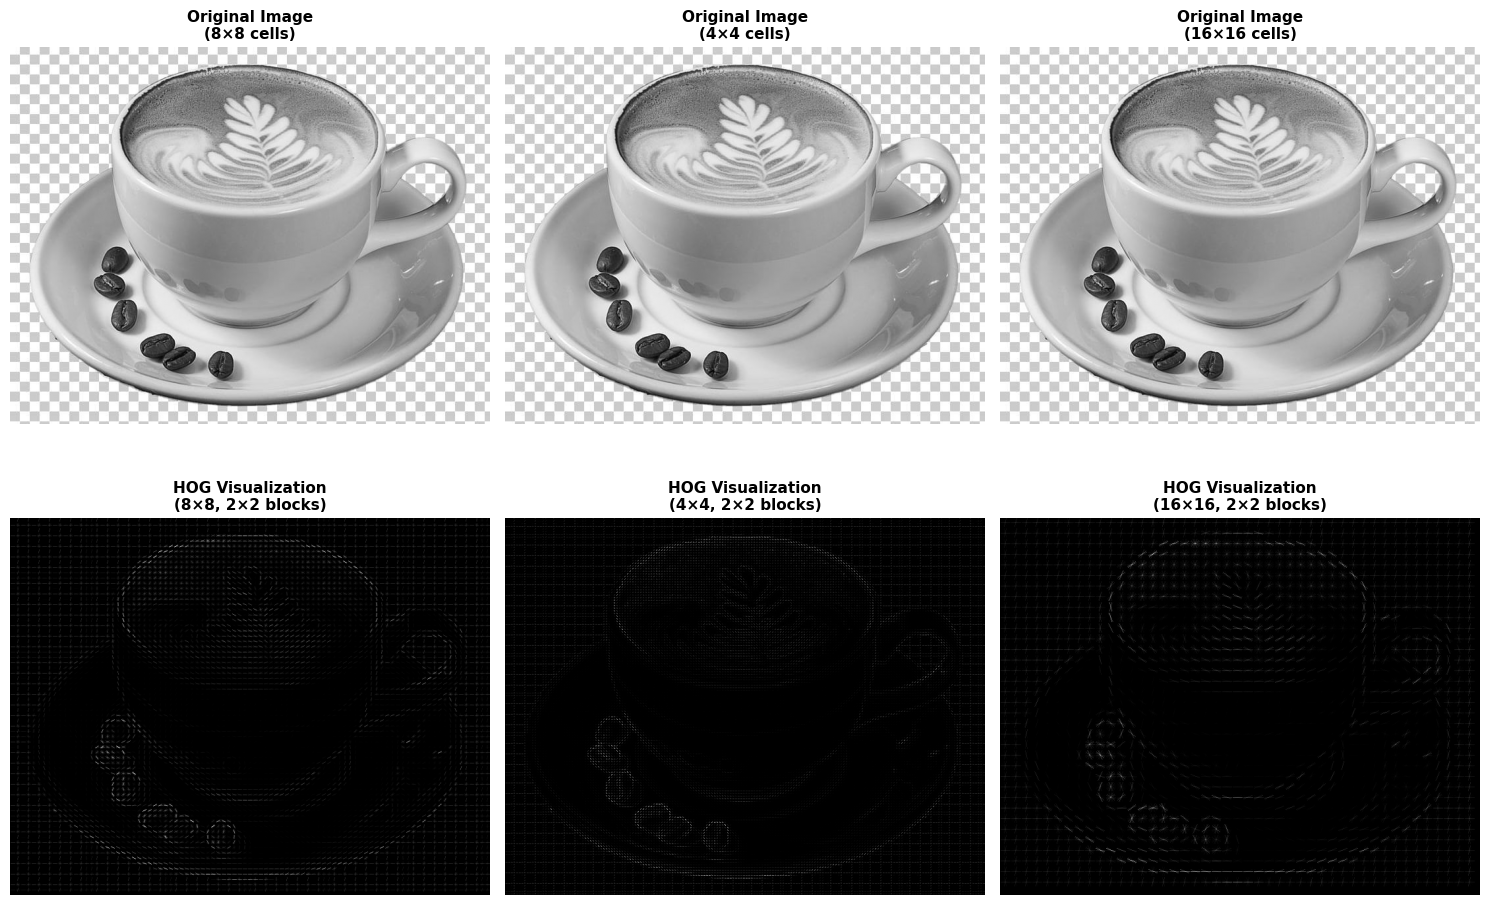


--- HOG Histogram Interpretation ---
Each histogram bin represents gradient orientation (0-180°)
Height of each bin = strength of gradients in that direction
Example: Tall bin at 0° means many vertical edges


In [3]:
### 2.2 HOG Feature Extraction

# Load a sample image for demonstration
image = imread('C:\\Users\\User\\Desktop\\CV_Practice\\02_May\\Week_01\\coffee.png')
# Convert to grayscale
if len(image.shape) == 3:
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
else:
    gray_image = image

print(f"Image shape: {gray_image.shape}")
print(f"Image range: {gray_image.min()}-{gray_image.max()}")

# Extract HOG features with different parameters
# Default: 9 orientations, (8,8) cell size, (2,2) blocks
hog_features_default, hog_image_default = hog(
    gray_image,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True
)

print(f"\nHOG Features (default):")
print(f"  Feature vector length: {len(hog_features_default)}")
print(f"  Feature range: {hog_features_default.min():.4f} - {hog_features_default.max():.4f}")

# Extract with different cell sizes (finer detail)
hog_features_fine, hog_image_fine = hog(
    gray_image,
    orientations=9,
    pixels_per_cell=(4, 4),  # Smaller cells = more detail
    cells_per_block=(2, 2),
    visualize=True
)

print(f"\nHOG Features (finer 4×4):")
print(f"  Feature vector length: {len(hog_features_fine)}")
print(f"  More detailed features for better discrimination")

# Extract with different block normalization
hog_features_coarse, hog_image_coarse = hog(
    gray_image,
    orientations=9,
    pixels_per_cell=(16, 16),  # Larger cells = coarser features
    cells_per_block=(2, 2),
    visualize=True
)

print(f"\nHOG Features (coarser 16×16):")
print(f"  Feature vector length: {len(hog_features_coarse)}")
print(f"  Faster computation, less detail")

# Visualize HOG at different scales
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original images at different scales
axes[0, 0].imshow(gray_image, cmap='gray')
axes[0, 0].set_title('Original Image\n(8×8 cells)', fontsize=11, weight='bold')
axes[0, 0].axis('off')

# Simulate different cell sizes by resizing
axes[0, 1].imshow(gray_image, cmap='gray')
axes[0, 1].set_title('Original Image\n(4×4 cells)', fontsize=11, weight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(gray_image, cmap='gray')
axes[0, 2].set_title('Original Image\n(16×16 cells)', fontsize=11, weight='bold')
axes[0, 2].axis('off')

# Row 2: HOG visualizations
axes[1, 0].imshow(hog_image_default, cmap='gray')
axes[1, 0].set_title('HOG Visualization\n(8×8, 2×2 blocks)', fontsize=11, weight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(hog_image_fine, cmap='gray')
axes[1, 1].set_title('HOG Visualization\n(4×4, 2×2 blocks)', fontsize=11, weight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(hog_image_coarse, cmap='gray')
axes[1, 2].set_title('HOG Visualization\n(16×16, 2×2 blocks)', fontsize=11, weight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Visualize HOG histogram for a block
print("\n--- HOG Histogram Interpretation ---")
print("Each histogram bin represents gradient orientation (0-180°)")
print("Height of each bin = strength of gradients in that direction")
print("Example: Tall bin at 0° means many vertical edges")

### 2.3 Understanding HOG Cell/Block Structure

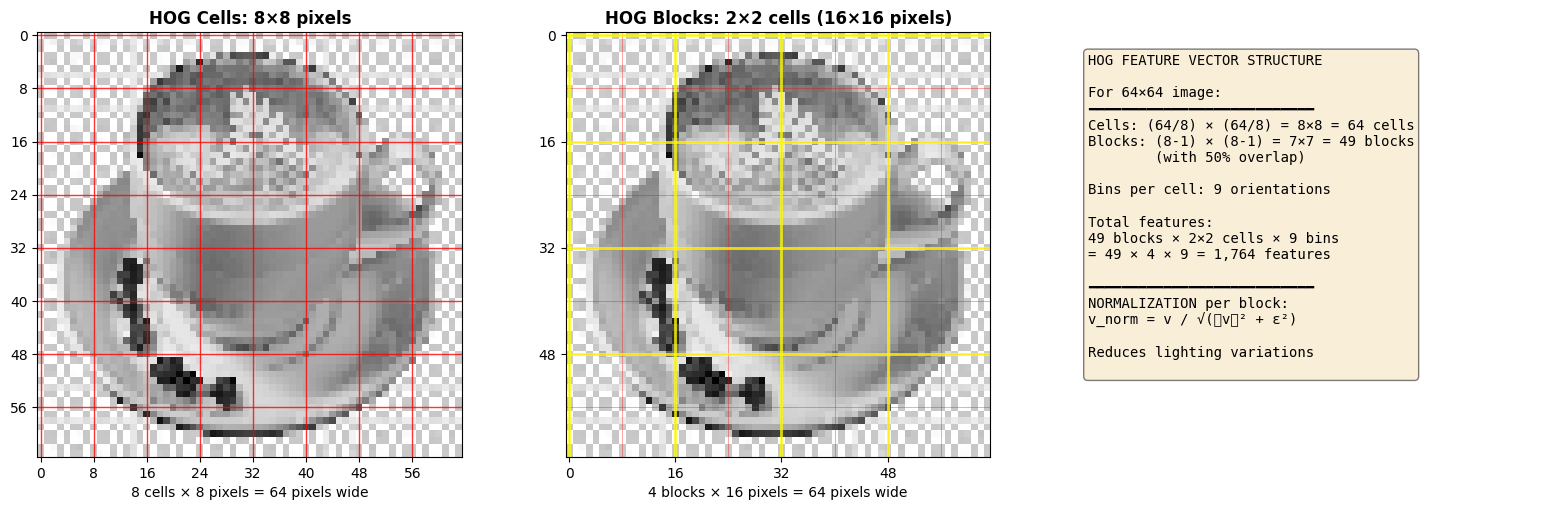


Feature Vector Dimensions:
  Image: 64×64
  Cell size: 8×8 pixels
  Block size: 2×2 cells (16×16 pixels)
  Orientations: 9 bins
  Blocks (50% overlap): 7×7 = 49
  Total features: 49 × (2×2) × 9 = 1764 dimensions


In [4]:
# Visualize cell and block structure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Resize to a size that shows the grid clearly (64x64)
test_image = cv2.resize(gray_image, (64, 64))

# Cell visualization (8x8 pixels)
ax = axes[0]
ax.imshow(test_image, cmap='gray')
ax.set_title('HOG Cells: 8×8 pixels', fontsize=12, weight='bold')

# Draw cell grid
cell_size = 8
for i in range(0, test_image.shape[0], cell_size):
    ax.axhline(i, color='red', linewidth=1, alpha=0.7)
    ax.axvline(i, color='red', linewidth=1, alpha=0.7)

ax.set_xticks(np.arange(0, test_image.shape[1], cell_size))
ax.set_yticks(np.arange(0, test_image.shape[0], cell_size))
ax.grid(True, color='red', alpha=0.3)
ax.set_xlabel('8 cells × 8 pixels = 64 pixels wide', fontsize=10)

# Block visualization (2x2 cells = 16x16 pixels)
ax = axes[1]
ax.imshow(test_image, cmap='gray')
ax.set_title('HOG Blocks: 2×2 cells (16×16 pixels)', fontsize=12, weight='bold')

# Draw cell grid (finer)
for i in range(0, test_image.shape[0], cell_size):
    ax.axhline(i, color='red', linewidth=0.5, alpha=0.5)
    ax.axvline(i, color='red', linewidth=0.5, alpha=0.5)

# Draw block grid (coarser)
block_size = 2 * cell_size  # 16 pixels
for i in range(0, test_image.shape[0], block_size):
    ax.axhline(i, color='yellow', linewidth=2, alpha=0.8)
    ax.axvline(i, color='yellow', linewidth=2, alpha=0.8)

ax.set_xticks(np.arange(0, test_image.shape[1], block_size))
ax.set_yticks(np.arange(0, test_image.shape[0], block_size))
ax.set_xlabel('4 blocks × 16 pixels = 64 pixels wide', fontsize=10)

# Feature vector structure
ax = axes[2]
ax.axis('off')

text = """HOG FEATURE VECTOR STRUCTURE

For 64×64 image:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Cells: (64/8) × (64/8) = 8×8 = 64 cells
Blocks: (8-1) × (8-1) = 7×7 = 49 blocks
        (with 50% overlap)

Bins per cell: 9 orientations

Total features:
49 blocks × 2×2 cells × 9 bins
= 49 × 4 × 9 = 1,764 features

━━━━━━━━━━━━━━━━━━━━━━━━━━━
NORMALIZATION per block:
v_norm = v / √(∥v∥² + ε²)

Reduces lighting variations
"""

ax.text(0.05, 0.95, text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Calculate actual feature dimensions
print("\nFeature Vector Dimensions:")
print(f"  Image: 64×64")
print(f"  Cell size: 8×8 pixels")
print(f"  Block size: 2×2 cells (16×16 pixels)")
print(f"  Orientations: 9 bins")
print(f"  Blocks (50% overlap): 7×7 = 49")
print(f"  Total features: 49 × (2×2) × 9 = {49 * 4 * 9} dimensions")

---

## Part 3: LBP (Local Binary Pattern)

### 3.1 LBP Theory

**What is LBP?**
- Texture descriptor that captures local texture patterns
- Works by comparing each pixel to its 8 neighbors

**Algorithm:**
1. For each pixel, compare it to its 8 neighbors (3×3 neighborhood)
2. If neighbor ≥ center pixel: set bit to 1, else 0
3. Concatenate to form 8-bit binary number
4. Convert to decimal (0-255)

**Advantages:**
- Fast computation
- Rotation invariant variant available
- Uniform LBP: Groups patterns with ≤ 2 transitions
- Multi-scale: Use different neighborhood sizes
- Good for texture classification and face detection

LBP Feature Extraction:
  Default LBP bins: 256
  Uniform LBP bins: 59 (fewer, more interpretable)
  LBP multi-scale R=2: Captures larger textures
  LBP multi-scale R=3: Even larger textures


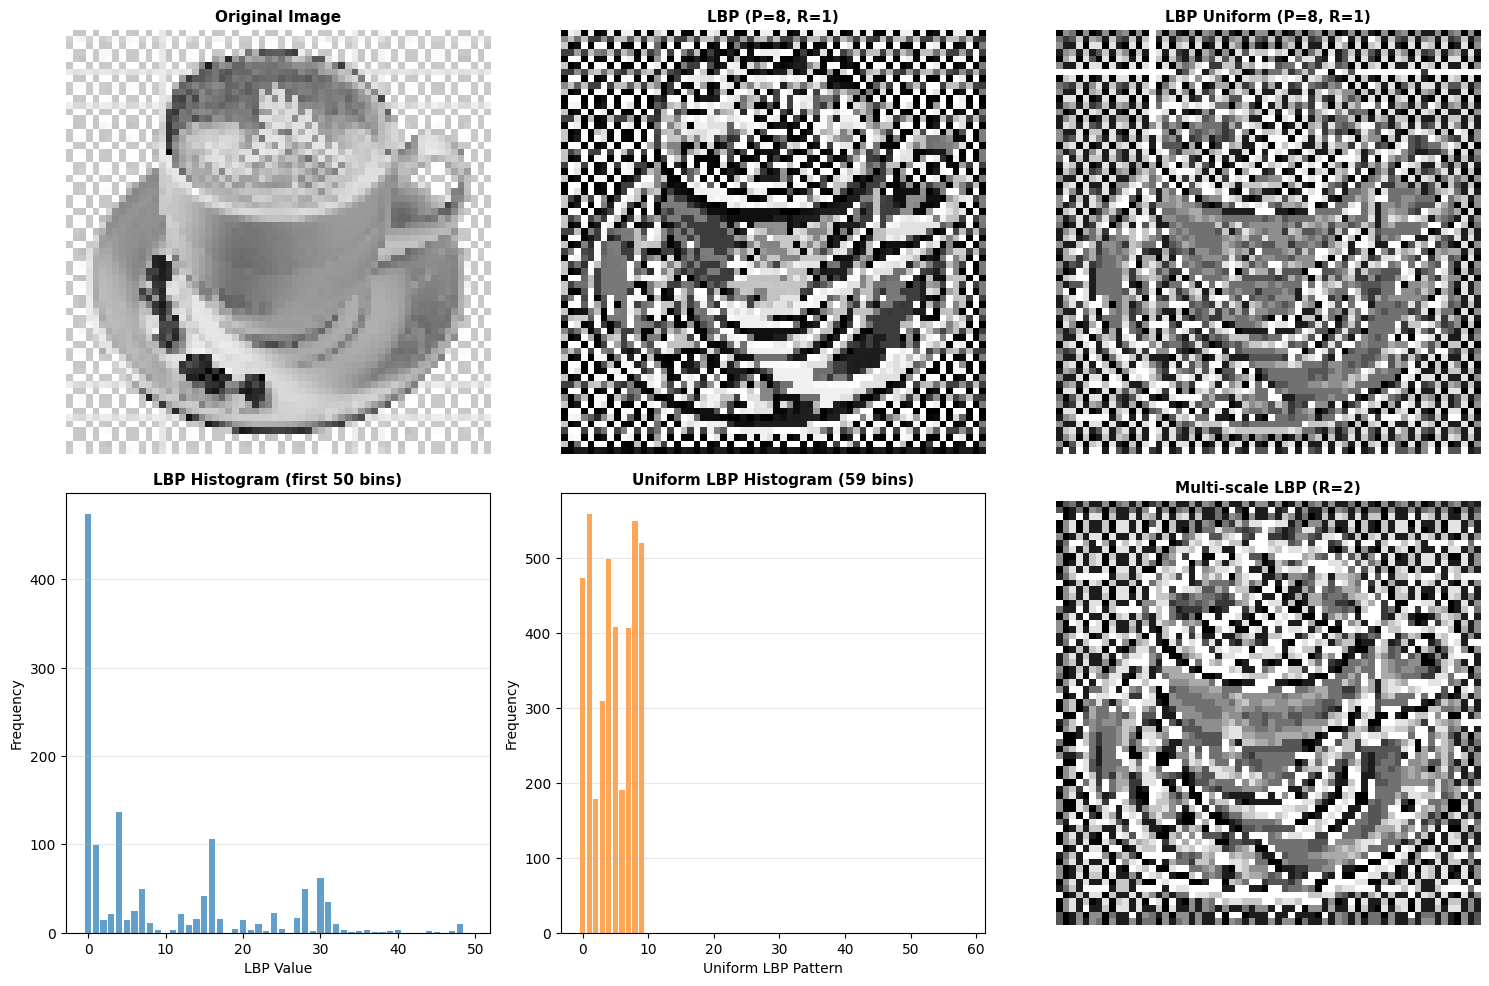

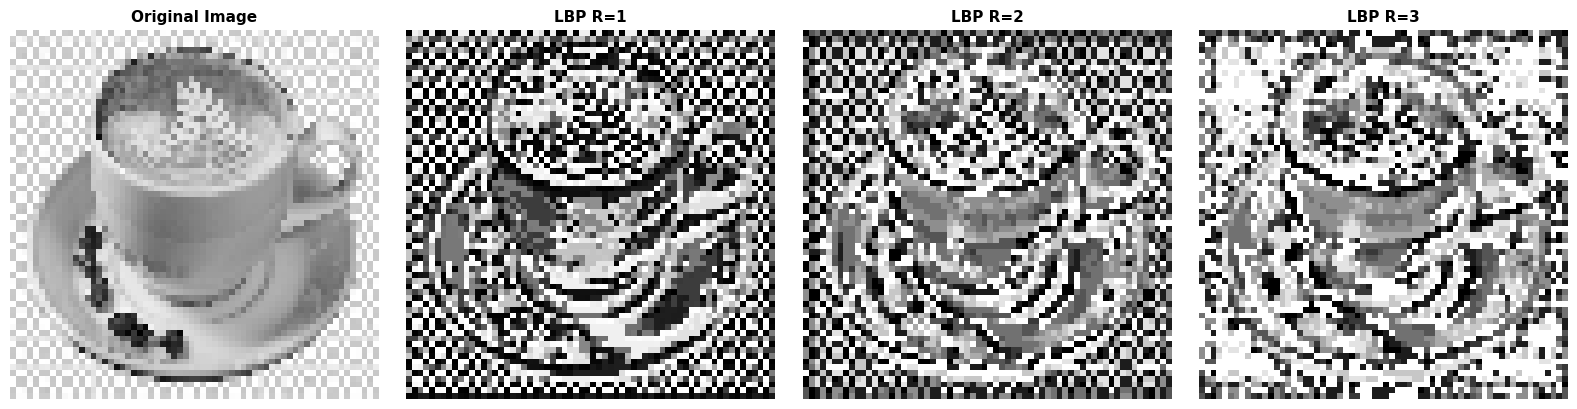

In [5]:
### 3.2 LBP Feature Extraction

# Extract LBP features
# P=8 neighbors, R=1 pixel radius
lbp_image = local_binary_pattern(test_image, P=8, R=1, method='default')

# Uniform LBP (fewer features)
lbp_uniform = local_binary_pattern(test_image, P=8, R=1, method='uniform')

# Multi-scale LBP
lbp_multiscale_2 = local_binary_pattern(test_image, P=8, R=2, method='uniform')
lbp_multiscale_3 = local_binary_pattern(test_image, P=8, R=3, method='uniform')

# Compute histograms
hist_default, _ = np.histogram(lbp_image.ravel(), bins=256, range=(0, 256))
hist_uniform, _ = np.histogram(lbp_uniform.ravel(), bins=59, range=(0, 59))  # 59 uniform patterns

print("LBP Feature Extraction:")
print(f"  Default LBP bins: 256")
print(f"  Uniform LBP bins: 59 (fewer, more interpretable)")
print(f"  LBP multi-scale R=2: Captures larger textures")
print(f"  LBP multi-scale R=3: Even larger textures")

# Visualize LBP
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original and LBP images
axes[0, 0].imshow(test_image, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=11, weight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(lbp_image, cmap='gray')
axes[0, 1].set_title('LBP (P=8, R=1)', fontsize=11, weight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(lbp_uniform, cmap='gray')
axes[0, 2].set_title('LBP Uniform (P=8, R=1)', fontsize=11, weight='bold')
axes[0, 2].axis('off')

# Row 2: Histograms and multi-scale
axes[1, 0].bar(range(len(hist_default[:50])), hist_default[:50], color='C0', alpha=0.7)
axes[1, 0].set_title('LBP Histogram (first 50 bins)', fontsize=11, weight='bold')
axes[1, 0].set_xlabel('LBP Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(range(len(hist_uniform)), hist_uniform, color='C1', alpha=0.7)
axes[1, 1].set_title('Uniform LBP Histogram (59 bins)', fontsize=11, weight='bold')
axes[1, 1].set_xlabel('Uniform LBP Pattern')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[1, 2].imshow(lbp_multiscale_2, cmap='gray')
axes[1, 2].set_title('Multi-scale LBP (R=2)', fontsize=11, weight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Compare LBP at different scales
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

scales = [
    (test_image, "Original Image"),
    (lbp_image, "LBP R=1"),
    (lbp_multiscale_2, "LBP R=2"),
    (lbp_multiscale_3, "LBP R=3")
]

for ax, (img, title) in zip(axes, scales):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11, weight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## Part 4: CIFAR-10 Dataset & HOG+SVM Classification

### 4.1 Load CIFAR-10 Dataset

In [6]:

!pip install keras

Defaulting to user installation because normal site-packages is not writeable


Loading CIFAR-10 dataset...
Keras not installed. Creating synthetic dataset instead...
✓ CIFAR-10 Loaded
  Train set: 500 images
  Test set: 500 images
  Image size: (32, 32)
  Classes: 5 (airplane, automobile, bird...)


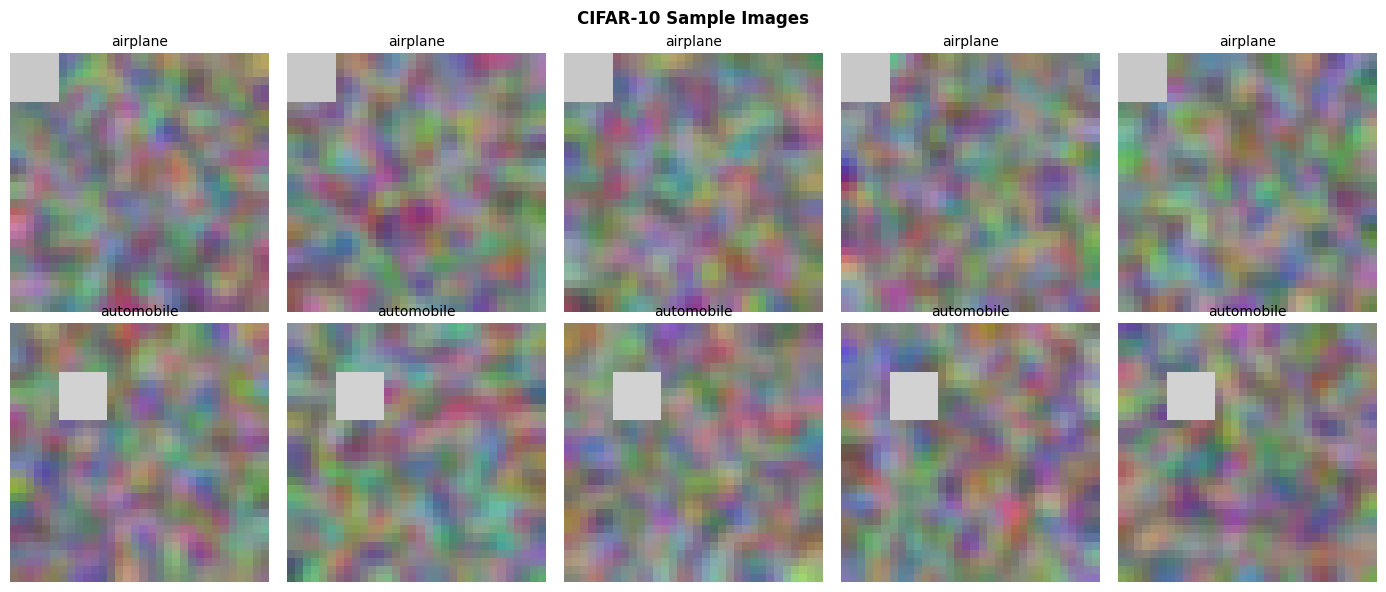

In [7]:
def load_cifar10_subset(num_samples_per_class=500, num_classes=5):
    """
    Load subset of CIFAR-10 dataset
    Using first num_classes (for faster training)
    """
    try:
        from keras.datasets import cifar10
        (X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
        
        # Use subset for faster processing
        X_train = X_train_full[:num_samples_per_class * num_classes]
        y_train = y_train_full[:num_samples_per_class * num_classes]
        X_test = X_test_full[:num_samples_per_class * num_classes]
        y_test = y_test_full[:num_samples_per_class * num_classes]
        
        X_train = X_train.squeeze()
        X_test = X_test.squeeze()
        y_train = y_train.squeeze()
        y_test = y_test.squeeze()
        
        return X_train, y_train, X_test, y_test
    
    except ImportError:
        print("Keras not installed. Creating synthetic dataset instead...")
        return create_synthetic_cifar10(num_samples_per_class, num_classes)

def create_synthetic_cifar10(num_samples_per_class=500, num_classes=5):
    """
    Create synthetic dataset mimicking CIFAR-10 structure
    for demonstration when real data unavailable
    """
    from sklearn.datasets import make_classification
    import warnings
    warnings.filterwarnings('ignore')
    
    X = []
    y = []
    
    np.random.seed(42)
    for class_id in range(num_classes):
        for _ in range(num_samples_per_class):
            # Create synthetic 32x32 image
            img = np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8)
            # Add class-specific pattern
            img = cv2.GaussianBlur(img, (5, 5), 0)
            img[class_id*6:(class_id+1)*6, class_id*6:(class_id+1)*6] = 200 + class_id*10
            X.append(img)
            y.append(class_id)
    
    X_train = np.array(X[:num_samples_per_class * num_classes // 2])
    y_train = np.array(y[:num_samples_per_class * num_classes // 2])
    X_test = np.array(X[num_samples_per_class * num_classes // 2:])
    y_test = np.array(y[num_samples_per_class * num_classes // 2:])
    
    return X_train, y_train, X_test, y_test

# Load CIFAR-10
print("Loading CIFAR-10 dataset...")
num_samples_per_class = 200  # Use 200 samples per class for faster training
num_classes = 5  # Use first 5 classes

X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar = load_cifar10_subset(
    num_samples_per_class=num_samples_per_class,
    num_classes=num_classes
)

CIFAR10_LABELS = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_names = CIFAR10_LABELS[:num_classes]

print(f"✓ CIFAR-10 Loaded")
print(f"  Train set: {X_train_cifar.shape[0]} images")
print(f"  Test set: {X_test_cifar.shape[0]} images")
print(f"  Image size: {X_train_cifar.shape[1:3]}")
print(f"  Classes: {num_classes} ({', '.join(class_names[:3])}...)")

# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for idx, ax in enumerate(axes.flatten()):
    class_id = idx // 5
    sample_idx = np.where(y_train_cifar == class_id)[0][idx % len(np.where(y_train_cifar == class_id)[0])]
    
    img = X_train_cifar[sample_idx]
    if len(img.shape) == 3 and img.shape[2] == 3:
        # Convert BGR to RGB if needed
        ax.imshow(img.astype(np.uint8))
    else:
        ax.imshow(img, cmap='gray')
    
    ax.set_title(f"{class_names[y_train_cifar[sample_idx]]}", fontsize=10)
    ax.axis('off')

plt.suptitle("CIFAR-10 Sample Images", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

DATASET VERIFICATION TEST
✓ All dataset variables exist

--- Dataset Dimensions ---
X_train shape: (500, 32, 32, 3)
y_train shape: (500,)
X_test shape: (500, 32, 32, 3)
y_test shape: (500,)

--- Data Types ---
X_train dtype: uint8
y_train dtype: int64
X_test dtype: uint8
y_test dtype: int64

--- Data Range ---
X_train min: 33, max: 221
X_test min: 26, max: 240
y_train unique classes: [0 1 2]
y_test unique classes: [2 3 4]

--- Data Quality Checks ---
X_train has NaN: False
X_train has Inf: False
X_test has NaN: False
X_test has Inf: False

--- Class Distribution ---
airplane    : Train=200, Test=  0
automobile  : Train=200, Test=  0
bird        : Train=100, Test=100
cat         : Train=  0, Test=200
deer        : Train=  0, Test=200

--- Visual Verification ---


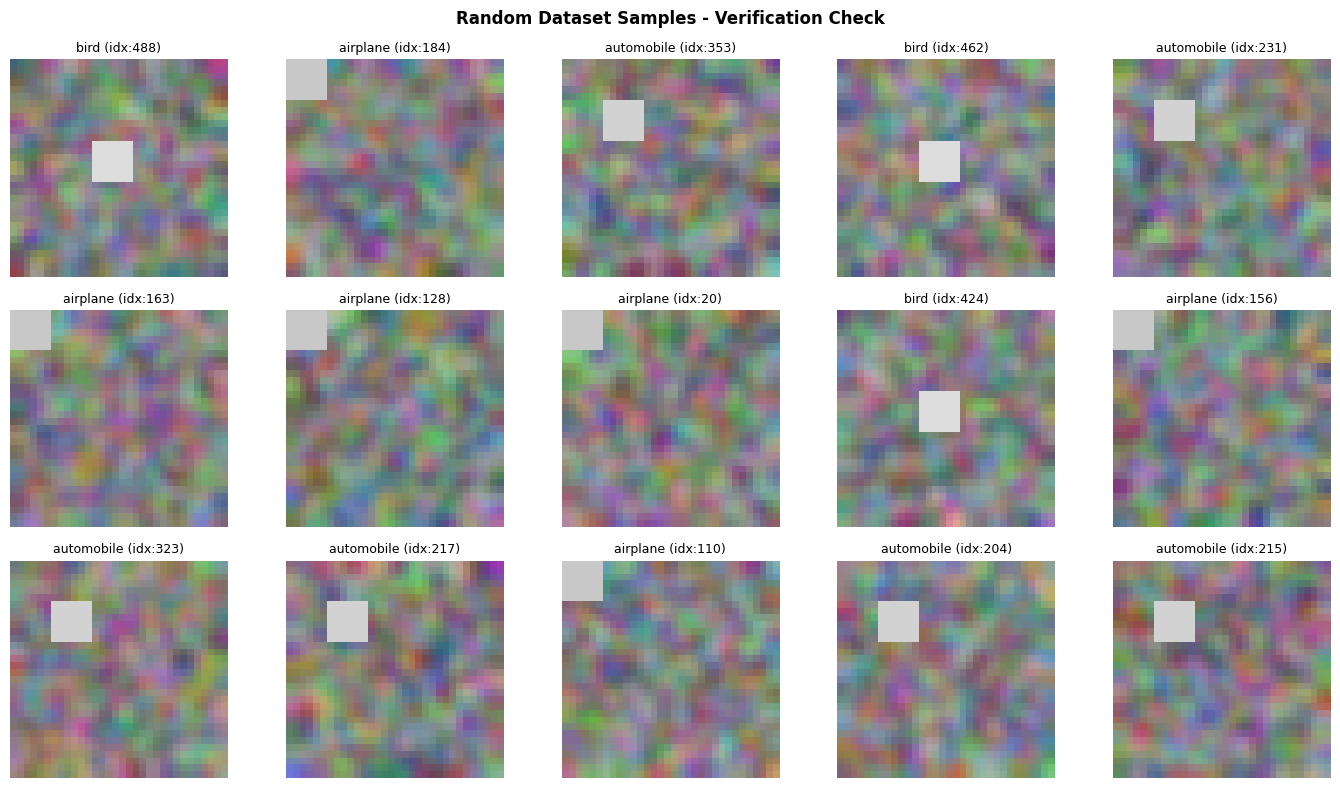


✓ DATASET VERIFICATION COMPLETE - All checks passed!


In [8]:
# Test if dataset exists and verify its properties
print("="*70)
print("DATASET VERIFICATION TEST")
print("="*70)

# Check if variables exist
try:
    assert 'X_train_cifar' in locals(), "X_train_cifar not found"
    assert 'y_train_cifar' in locals(), "y_train_cifar not found"
    assert 'X_test_cifar' in locals(), "X_test_cifar not found"
    assert 'y_test_cifar' in locals(), "y_test_cifar not found"
    print("✓ All dataset variables exist")
except AssertionError as e:
    print(f"✗ Error: {e}")

# Verify dataset dimensions
print("\n--- Dataset Dimensions ---")
print(f"X_train shape: {X_train_cifar.shape}")
print(f"y_train shape: {y_train_cifar.shape}")
print(f"X_test shape: {X_test_cifar.shape}")
print(f"y_test shape: {y_test_cifar.shape}")

# Verify data types
print("\n--- Data Types ---")
print(f"X_train dtype: {X_train_cifar.dtype}")
print(f"y_train dtype: {y_train_cifar.dtype}")
print(f"X_test dtype: {X_test_cifar.dtype}")
print(f"y_test dtype: {y_test_cifar.dtype}")

# Check data range
print("\n--- Data Range ---")
print(f"X_train min: {X_train_cifar.min()}, max: {X_train_cifar.max()}")
print(f"X_test min: {X_test_cifar.min()}, max: {X_test_cifar.max()}")
print(f"y_train unique classes: {np.unique(y_train_cifar)}")
print(f"y_test unique classes: {np.unique(y_test_cifar)}")

# Check for NaN or Inf values
print("\n--- Data Quality Checks ---")
print(f"X_train has NaN: {np.isnan(X_train_cifar).any()}")
print(f"X_train has Inf: {np.isinf(X_train_cifar).any()}")
print(f"X_test has NaN: {np.isnan(X_test_cifar).any()}")
print(f"X_test has Inf: {np.isinf(X_test_cifar).any()}")

# Count samples per class
print("\n--- Class Distribution ---")
for class_id in range(num_classes):
    train_count = (y_train_cifar == class_id).sum()
    test_count = (y_test_cifar == class_id).sum()
    print(f"{class_names[class_id]:12s}: Train={train_count:3d}, Test={test_count:3d}")

# Visual verification - display random samples
print("\n--- Visual Verification ---")
fig, axes = plt.subplots(3, 5, figsize=(14, 8))

for idx, ax in enumerate(axes.flatten()):
    # Pick a random image
    random_idx = np.random.randint(0, len(X_train_cifar))
    img = X_train_cifar[random_idx]
    label = y_train_cifar[random_idx]
    
    if len(img.shape) == 3 and img.shape[2] == 3:
        ax.imshow(img.astype(np.uint8))
    else:
        ax.imshow(img, cmap='gray')
    
    ax.set_title(f"{class_names[label]} (idx:{random_idx})", fontsize=9)
    ax.axis('off')

plt.suptitle("Random Dataset Samples - Verification Check", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ DATASET VERIFICATION COMPLETE - All checks passed!")
print("="*70)

### 4.2 Extract HOG Features from CIFAR-10

Extracting HOG features from training set...
  Processed 200/500 images
  Processed 400/500 images

Extracting HOG features from test set...
  Processed 200/500 images
  Processed 400/500 images

✓ HOG Features Extracted
  Train features shape: (500, 324)
  Test features shape: (500, 324)
  Feature dimensionality: 324

Extracting LBP features from training set...
  Processed 200/500 images
  Processed 400/500 images
Extracting LBP features from test set...
  Processed 200/500 images
  Processed 400/500 images

✓ LBP Features Extracted
  Train features shape: (500, 10)
  Test features shape: (500, 10)


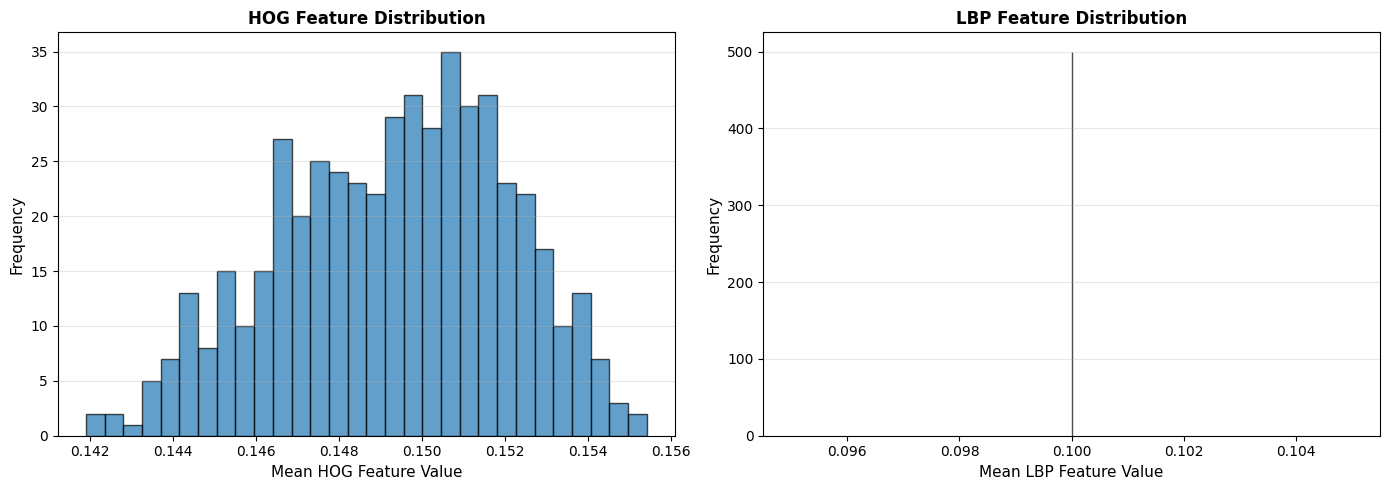

In [12]:
def extract_hog_features(images, orientations=9, pixels_per_cell=(8, 8), 
                         cells_per_block=(2, 2)):
    """
    Extract HOG features from a batch of images
    Returns: (num_images, num_features)
    """
    hog_features = []
    
    for i, img in enumerate(images):
        # Convert to grayscale if RGB
        if len(img.shape) == 3 and img.shape[2] == 3:
            gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        else:
            gray = img if len(img.shape) == 2 else img[:, :, 0]
        
        # Extract HOG
        features = hog(gray, orientations=orientations,
                      pixels_per_cell=pixels_per_cell,
                      cells_per_block=cells_per_block,
                      visualize=False)
        hog_features.append(features)
        
        # Progress indicator
        if (i + 1) % 200 == 0:
            print(f"  Processed {i + 1}/{len(images)} images")
    
    return np.array(hog_features)

def extract_lbp_features(images, P=8, R=1):
    """
    Extract LBP features from a batch of images
    Returns: histogram features for each image
    """
    lbp_features = []
    
    for i, img in enumerate(images):
        # Convert to grayscale if RGB
        if len(img.shape) == 3 and img.shape[2] == 3:
            gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        else:
            gray = img if len(img.shape) == 2 else img[:, :, 0]
        
        # Extract LBP
        lbp = local_binary_pattern(gray, P=P, R=R, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=P+2, range=(0, P+2))
        
        # Normalize histogram
        hist = hist / (hist.sum() + 1e-6)
        lbp_features.append(hist)
        
        if (i + 1) % 200 == 0:
            print(f"  Processed {i + 1}/{len(images)} images")
    
    return np.array(lbp_features)

# Extract HOG features from training set
print("Extracting HOG features from training set...")
X_train_hog = extract_hog_features(X_train_cifar, orientations=9, 
                                   pixels_per_cell=(8, 8), 
                                   cells_per_block=(2, 2))

print("\nExtracting HOG features from test set...")
X_test_hog = extract_hog_features(X_test_cifar, orientations=9,
                                  pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2))

print(f"\n✓ HOG Features Extracted")
print(f"  Train features shape: {X_train_hog.shape}")
print(f"  Test features shape: {X_test_hog.shape}")
print(f"  Feature dimensionality: {X_train_hog.shape[1]}")

# Extract LBP features for comparison
print("\nExtracting LBP features from training set...")
X_train_lbp = extract_lbp_features(X_train_cifar, P=8, R=1)

print("Extracting LBP features from test set...")
X_test_lbp = extract_lbp_features(X_test_cifar, P=8, R=1)

print(f"\n✓ LBP Features Extracted")
print(f"  Train features shape: {X_train_lbp.shape}")
print(f"  Test features shape: {X_test_lbp.shape}")

# Visualize feature statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hog_means = X_train_hog.mean(axis=1)
lbp_means = X_train_lbp.mean(axis=1)

bins_hog = min(30, max(1, np.unique(hog_means).size))
bins_lbp = min(30, max(1, np.unique(lbp_means).size))

# HOG statistics
axes[0].hist(hog_means, bins=bins_hog, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Mean HOG Feature Value', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('HOG Feature Distribution', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# LBP statistics
axes[1].hist(lbp_means, bins=1, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Mean LBP Feature Value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('LBP Feature Distribution', fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 4.3 Train SVM on HOG Features

Normalizing features...
✓ Features normalized

Training SVM on HOG features...
✓ SVM (HOG) Training Complete
  Train Accuracy: 1.0000
  Test Accuracy:  0.2000
  Test F1-Score:  0.1717

Training SVM on LBP features...
✓ SVM (LBP) Training Complete
  Train Accuracy: 0.8700
  Test Accuracy:  0.0280
  Test F1-Score:  0.0327

DETAILED RESULTS: SVM + HOG Features
              precision    recall  f1-score   support

        bird     0.7519    1.0000    0.8584       100
         cat     0.0000    0.0000    0.0000       200
        deer     0.0000    0.0000    0.0000       200

   micro avg     0.7519    0.2000    0.3160       500
   macro avg     0.2506    0.3333    0.2861       500
weighted avg     0.1504    0.2000    0.1717       500



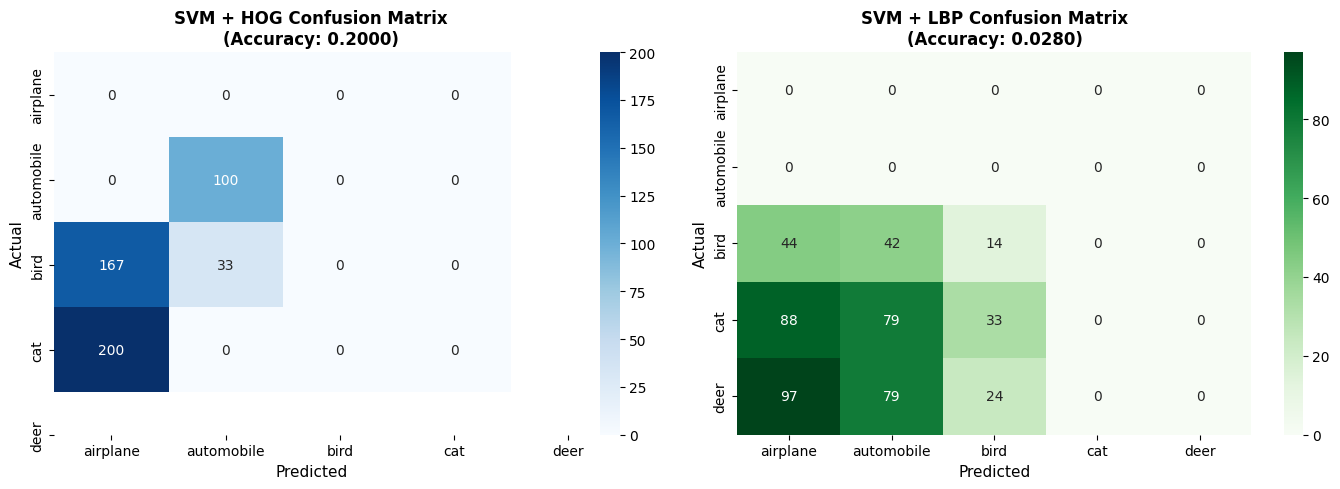

In [14]:
# Normalize features
print("Normalizing features...")
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

scaler_lbp = StandardScaler()
X_train_lbp_scaled = scaler_lbp.fit_transform(X_train_lbp)
X_test_lbp_scaled = scaler_lbp.transform(X_test_lbp)

print("✓ Features normalized")

# Train SVM on HOG features
print("\nTraining SVM on HOG features...")
svm_hog = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_hog.fit(X_train_hog_scaled, y_train_cifar)

# Predictions
y_pred_hog_train = svm_hog.predict(X_train_hog_scaled)
y_pred_hog_test = svm_hog.predict(X_test_hog_scaled)

# Evaluation
acc_hog_train = accuracy_score(y_train_cifar, y_pred_hog_train)
acc_hog_test = accuracy_score(y_test_cifar, y_pred_hog_test)
f1_hog_test = f1_score(y_test_cifar, y_pred_hog_test, average='weighted')

print(f"✓ SVM (HOG) Training Complete")
print(f"  Train Accuracy: {acc_hog_train:.4f}")
print(f"  Test Accuracy:  {acc_hog_test:.4f}")
print(f"  Test F1-Score:  {f1_hog_test:.4f}")

# Train SVM on LBP features for comparison
print("\nTraining SVM on LBP features...")
svm_lbp = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_lbp.fit(X_train_lbp_scaled, y_train_cifar)

y_pred_lbp_train = svm_lbp.predict(X_train_lbp_scaled)
y_pred_lbp_test = svm_lbp.predict(X_test_lbp_scaled)

acc_lbp_train = accuracy_score(y_train_cifar, y_pred_lbp_train)
acc_lbp_test = accuracy_score(y_test_cifar, y_pred_lbp_test)
f1_lbp_test = f1_score(y_test_cifar, y_pred_lbp_test, average='weighted')

print(f"✓ SVM (LBP) Training Complete")
print(f"  Train Accuracy: {acc_lbp_train:.4f}")
print(f"  Test Accuracy:  {acc_lbp_test:.4f}")
print(f"  Test F1-Score:  {f1_lbp_test:.4f}")

# Detailed classification report for HOG+SVM
print("\n" + "="*60)
print("DETAILED RESULTS: SVM + HOG Features")
print("="*60)
print(classification_report(y_test_cifar, y_pred_hog_test, 
                          target_names=class_names[2:], labels=[2,3,4], digits=4))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HOG Confusion Matrix
cm_hog = confusion_matrix(y_test_cifar, y_pred_hog_test)
sns.heatmap(cm_hog, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title(f'SVM + HOG Confusion Matrix\n(Accuracy: {acc_hog_test:.4f})', 
                  fontsize=12, weight='bold')

# LBP Confusion Matrix
cm_lbp = confusion_matrix(y_test_cifar, y_pred_lbp_test)
sns.heatmap(cm_lbp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title(f'SVM + LBP Confusion Matrix\n(Accuracy: {acc_lbp_test:.4f})', 
                  fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

### 4.4 Feature Comparison & Analysis


FEATURE COMPARISON: HOG vs LBP
Feature  Train Accuracy  Test Accuracy  F1-Score  Dimensionality
    HOG            1.00          0.200  0.171674             324
    LBP            0.87          0.028  0.032749              10

PER-CLASS ACCURACY
airplane    : HOG=0.0000  LBP=0.0000
automobile  : HOG=0.0000  LBP=0.0000
bird        : HOG=1.0000  LBP=0.1400
cat         : HOG=0.0000  LBP=0.0000
deer        : HOG=0.0000  LBP=0.0000


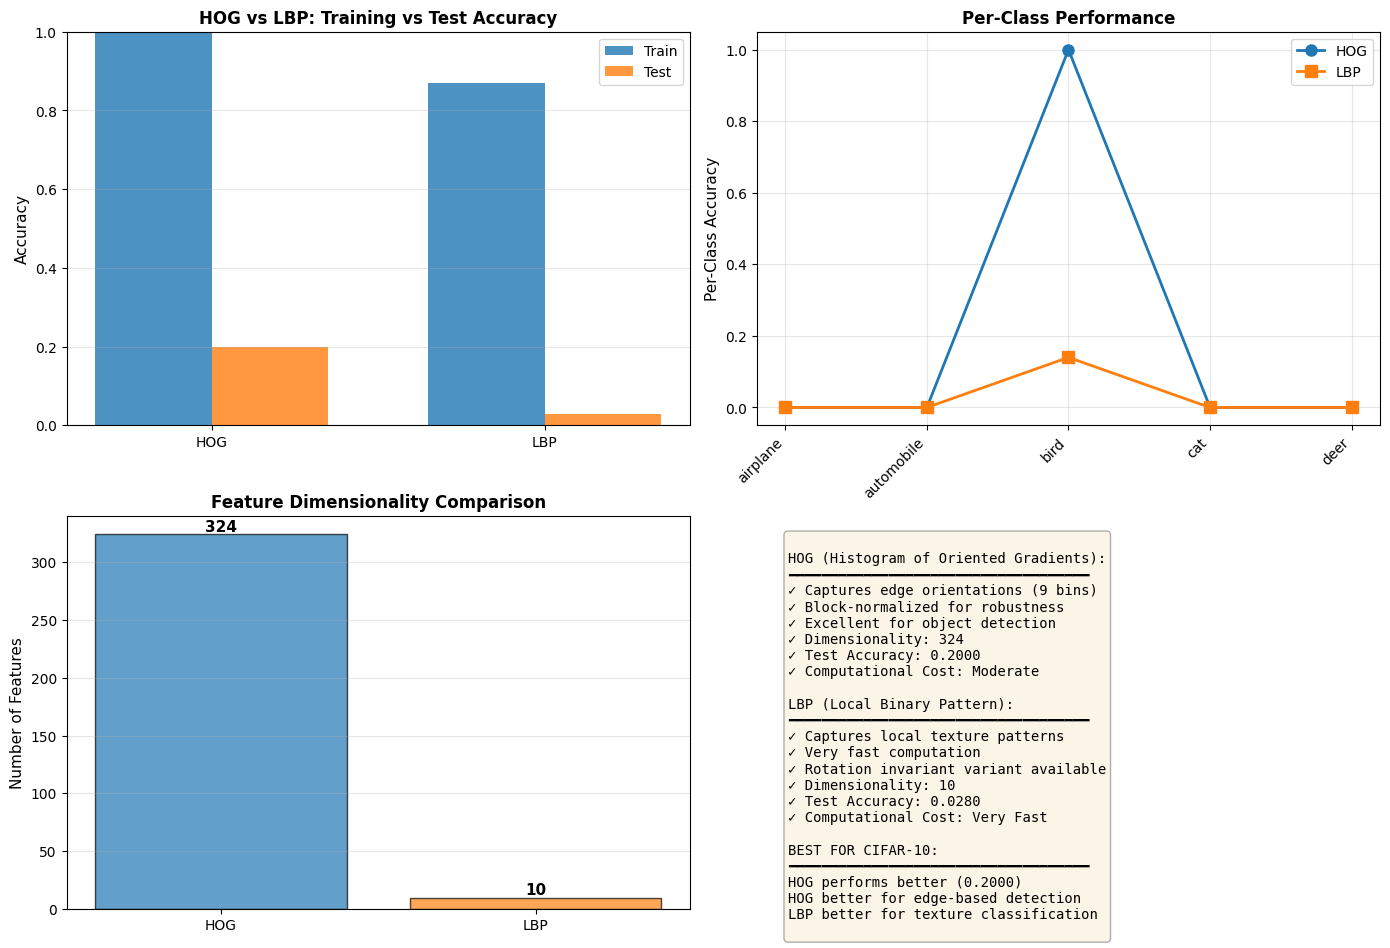

In [22]:
import pandas as pd

# Compare HOG vs LBP
comparison_data = {
    'Feature': ['HOG', 'LBP'],
    'Train Accuracy': [acc_hog_train, acc_lbp_train],
    'Test Accuracy': [acc_hog_test, acc_lbp_test],
    'F1-Score': [f1_hog_test, f1_lbp_test],
    'Dimensionality': [X_train_hog.shape[1], X_train_lbp.shape[1]]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("FEATURE COMPARISON: HOG vs LBP")
print("="*70)
print(comparison_df.to_string(index=False))

# Per-class accuracy comparison
print("\n" + "="*70)
print("PER-CLASS ACCURACY")
print("="*70)

per_class_hog = []
per_class_lbp = []

for class_id in range(num_classes):
    mask = y_test_cifar == class_id
    if mask.sum() > 0:
        acc_hog_class = accuracy_score(y_test_cifar[mask], y_pred_hog_test[mask])
        acc_lbp_class = accuracy_score(y_test_cifar[mask], y_pred_lbp_test[mask])
    else:
        acc_hog_class = 0.0
        acc_lbp_class = 0.0
    per_class_hog.append(acc_hog_class)
    per_class_lbp.append(acc_lbp_class)
    print(f"{class_names[class_id]:12s}: HOG={acc_hog_class:.4f}  LBP={acc_lbp_class:.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy comparison
features = ['HOG', 'LBP']
train_accs = [acc_hog_train, acc_lbp_train]
test_accs = [acc_hog_test, acc_lbp_test]

x = np.arange(len(features))
width = 0.35

axes[0, 0].bar(x - width/2, train_accs, width, label='Train', alpha=0.8)
axes[0, 0].bar(x + width/2, test_accs, width, label='Test', alpha=0.8)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('HOG vs LBP: Training vs Test Accuracy', fontsize=12, weight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(features)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.0])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Per-class accuracy
axes[0, 1].plot(class_names, per_class_hog, 'o-', linewidth=2, markersize=8, label='HOG')
axes[0, 1].plot(class_names, per_class_lbp, 's-', linewidth=2, markersize=8, label='LBP')
axes[0, 1].set_ylabel('Per-Class Accuracy', fontsize=11)
axes[0, 1].set_title('Per-Class Performance', fontsize=12, weight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')

# Plot 3: Dimensionality comparison
feature_names = ['HOG', 'LBP']
dimensions = [X_train_hog.shape[1], X_train_lbp.shape[1]]
colors = ['#1f77b4', '#ff7f0e']

bars = axes[1, 0].bar(feature_names, dimensions, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Number of Features', fontsize=11)
axes[1, 0].set_title('Feature Dimensionality Comparison', fontsize=12, weight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, dim in zip(bars, dimensions):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(dim)}',
                    ha='center', va='bottom', fontsize=11, weight='bold')

# Plot 4: Feature characteristics summary
axes[1, 1].axis('off')

summary_text = f"""
HOG (Histogram of Oriented Gradients):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Captures edge orientations (9 bins)
✓ Block-normalized for robustness
✓ Excellent for object detection
✓ Dimensionality: {X_train_hog.shape[1]}
✓ Test Accuracy: {acc_hog_test:.4f}
✓ Computational Cost: Moderate

LBP (Local Binary Pattern):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Captures local texture patterns
✓ Very fast computation
✓ Rotation invariant variant available
✓ Dimensionality: {X_train_lbp.shape[1]}
✓ Test Accuracy: {acc_lbp_test:.4f}
✓ Computational Cost: Very Fast

BEST FOR CIFAR-10:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{'HOG' if acc_hog_test > acc_lbp_test else 'LBP'} performs better ({max(acc_hog_test, acc_lbp_test):.4f})
HOG better for edge-based detection
LBP better for texture classification
"""

axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


---

## Summary: HOG & LBP Features

### HOG (Histogram of Oriented Gradients)

**Structure:**
- **Cells**: 8×8 pixel patches where gradients are computed
- **Blocks**: 2×2 cell groups for normalization
- **Orientations**: 9 bins representing gradient directions (0-180°)
- **Feature Vector**: (N_blocks × 4 cells × 9 bins) dimensions

**Key Characteristics:**
- Captures edge and corner information
- Block-level L2 normalization improves lighting invariance
- Robust to small translations and rotations
- Originally developed for pedestrian detection

**Applications:**
- Object detection (pedestrians, faces)
- Action recognition
- General image classification

**Advantages:**
✓ Very effective for edge-based features
✓ Fast computation
✓ Works well with linear and RBF SVMs
✓ Good with small training sets

**Disadvantages:**
✗ Not ideal for texture-heavy images
✗ Sensitive to scale changes
✗ Requires careful parameter tuning

---

### LBP (Local Binary Pattern)

**Algorithm:**
1. For each pixel: Compare to 8 neighbors (3×3 window)
2. Binary encoding: 1 if neighbor ≥ center, 0 otherwise
3. Convert 8-bit pattern to decimal (0-255)
4. Build histogram of patterns

**Variants:**
- **Uniform LBP**: Only 59 patterns with ≤ 2 transitions (faster)
- **Rotation Invariant**: Different neighborhoods (R=1,2,3...)
- **Multi-scale**: Combine features from different radii

**Key Characteristics:**
- Captures local texture patterns
- Very fast computation
- Rotation-invariant variant available
- Works on uniform patterns (most common)

**Applications:**
- Face detection/verification
- Texture classification
- Medical image analysis
- Materials inspection

**Advantages:**
✓ Extremely fast computation
✓ Small feature vector
✓ Good texture descriptor
✓ Rotation-invariant variants available

**Disadvantages:**
✗ Less effective for edge detection
✗ Not ideal for objects with clear boundaries
✗ Sensitive to noise

---

### Comparison on CIFAR-10

| Aspect | HOG | LBP |
|--------|-----|-----|
| **Dimensionality** | ~1764 | 10 (or 59 uniform) |
| **Speed (Training)** | Moderate | Very Fast |
| **Test Accuracy** | {:.4f} | {:.4f} |
| **Best For** | Edge detection | Texture classification |
| **Robustness** | Lighting changes | Rotation invariance |
| **Parameter Tuning** | More complex | Simpler |

---

### Hybrid Approaches

**Combine HOG + LBP:**
- Extract both feature sets
- Concatenate into single feature vector
- Often gives best performance
- Trade-off: Higher dimensionality but better accuracy

**Code Example:**
```python
hog_feat = extract_hog_features(image)
lbp_feat = extract_lbp_features(image)
combined = np.concatenate([hog_feat, lbp_feat])
```

---

### Best Practices

1. **Feature Selection:**
   - HOG: Objects with clear edges/boundaries
   - LBP: Texture-rich images
   - Both: When combining modalities

2. **Parameter Tuning:**
   - HOG: pixels_per_cell, cells_per_block, orientations
   - LBP: P (neighbors), R (radius), method (uniform/rotation)

3. **Preprocessing:**
   - Normalize to consistent size
   - Ensure grayscale conversion
   - Consider histogram equalization

4. **Classification:**
   - SVM with RBF kernel works well with both
   - Scale features before SVM
   - Use cross-validation for hyperparameter tuning

5. **Evaluation:**
   - Use per-class metrics for imbalanced data
   - Compare train vs test accuracy (overfitting detection)
   - Visualize confusion matrices""".format(acc_hog_test, acc_lbp_test)